# Time series demo - Echo State Network

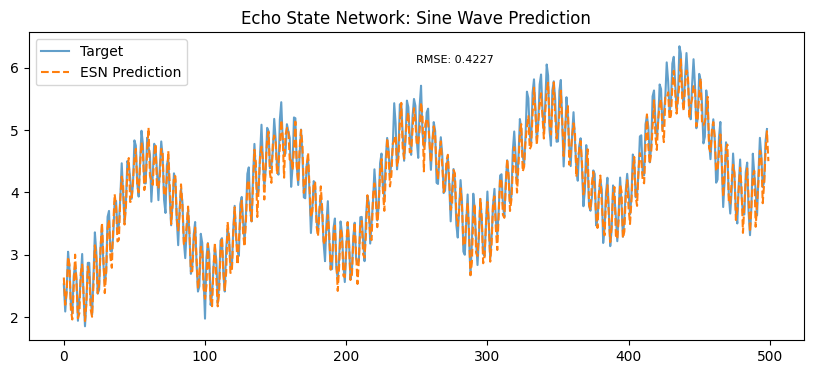

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
np.random.seed(42)

# 1. Setup and Parameters
n_inputs = 1
n_reservoir = 500  # Number of "neurons" in the reservoir
n_outputs = 1
spectral_radius = 0.9  # Keeps the reservoir stable
reg = 1e-4  # Regularization for the linear regression

# Generate some toy data
time = 100
train_len = 1000
test_len = 500
total_samples = train_len + test_len
first_harmonic = np.sin(np.linspace(0, time, total_samples))
second_harmonic = 0.5 * np.sin(20 * np.linspace(0, time, total_samples))
trend = np.linspace(0, 5, total_samples)
noise = 0.1 * np.random.randn(total_samples)
data = first_harmonic + second_harmonic + trend + noise


# 2. Initialize Random Weights
Win = (np.random.rand(n_reservoir, n_inputs) - 0.5) * 1.0
Wres = np.random.rand(n_reservoir, n_reservoir) - 0.5
# Scale Wres with respect to its spectral radius
rhoW = np.max(np.abs(np.linalg.eigvals(Wres)))
Wres *= spectral_radius / rhoW

# 3. Training: Collect States
states = np.zeros((n_reservoir, train_len))
x = np.zeros((n_reservoir, 1))

for t in range(train_len):
    u = data[t]
    # The core RC update equation
    x = np.tanh(np.dot(Win, u) + np.dot(Wres, x))
    states[:, t] = x.flatten()

# 4. Solve for Wout (Ridge Regression)
# Target is the data shifted by one step into the future
targets = data[1 : train_len + 1].reshape(1, -1)
Wout = np.dot(np.dot(targets, states.T), np.linalg.inv(np.dot(states, states.T) + reg * np.eye(n_reservoir)))

# 5. Prediction
test_outputs = []
for t in range(test_len):
    u = data[train_len + t]
    x = np.tanh(np.dot(Win, u) + np.dot(Wres, x))
    y = np.dot(Wout, x)
    test_outputs.append(y.flatten())
    
test_outputs = np.array(test_outputs)

rmse = root_mean_squared_error(data[train_len : train_len + test_len + 1], test_outputs.flatten())

# Visualize
plt.figure(figsize=(10, 4))
plt.plot(data[train_len+1 : train_len+test_len+1], label="Target", alpha=0.7)
plt.plot(test_outputs, '--', label="ESN Prediction")
plt.title("Echo State Network: Sine Wave Prediction")
plt.text(0.5, 0.9, f"RMSE: {rmse:.4f}", transform=plt.gca().transAxes, fontsize=8)
plt.legend()
plt.show()

# Classification demo - Liquid State Machine

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [30]:
# ==========================================
# 1. Liquid State Machine (Spiking Reservoir)
# ==========================================
class LiquidStateMachine:
    def __init__(self, input_size, res_size, leak=0.3, threshold=1.0, spectral_radius=0.9):
        self.res_size = res_size
        self.leak = leak
        self.threshold = threshold
        
        self.W_in = np.random.uniform(-10, 10, (res_size, input_size))
        # self.W_in = np.random.zipf(2.1, (res_size, input_size))
        
        # Random Recurrent Weights (The "Liquid")
        # W_res = np.random.uniform(-1, 1, (res_size, res_size))
        W_res = np.random.zipf(1.4, (res_size, res_size))
        
        # Scale the recurrent weights to ensure stable dynamics
        eigenvalues = np.linalg.eigvals(W_res)
        max_eig = np.max(np.abs(eigenvalues))
        self.W_res = W_res * (spectral_radius / max_eig)

    def get_liquid_state(self, sequence, return_spikes=False):
        """
        Passes a single temporal sequence through the reservoir.
        """
        seq_len = sequence.shape[0]
        voltages = np.zeros(self.res_size)
        spikes = np.zeros(self.res_size)
        
        spike_history = [] 
        liquid_state = np.zeros(self.res_size)

        for t in range(seq_len):
            # Leaky Integrate-and-Fire (LIF) dynamics
            input_stimulus = self.W_in @ sequence[t]
            recurrent_stimulus = self.W_res @ spikes
            
            # Update membrane voltage
            voltages = (1 - self.leak) * voltages + self.leak * (input_stimulus + recurrent_stimulus)
            
            # Check for spikes
            spikes = (voltages >= self.threshold).astype(float)
            
            # Reset voltage for neurons that fired
            voltages[spikes == 1] = 0.0
            
            # Accumulate spikes to form the final "liquid state" (firing rate)
            liquid_state += spikes
            if return_spikes:
                spike_history.append(spikes.copy())

        avg_firing_rate = liquid_state / seq_len
        
        if return_spikes:
            return avg_firing_rate, np.array(spike_history)
        return avg_firing_rate

In [31]:
print("Loading Toy Digits Dataset...")
digits = load_digits()
X_raw = digits.data  
y = digits.target    

# Normalize pixel values
X_raw = X_raw / 16.0 

# Reshape into temporal sequences: (samples, time_steps, features)
X = X_raw.reshape(-1, 64, 1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

RESERVOIR_SIZE = 600 

print(f"Initializing Liquid State Machine with {RESERVOIR_SIZE} neurons...")
print(f"Initializing Liquid State Machine with {RESERVOIR_SIZE} neurons...")
lsm = LiquidStateMachine(input_size=1, 
                         res_size=RESERVOIR_SIZE, 
                         leak=0.37, 
                         threshold=0.6,
                         spectral_radius=0.4)

print("Processing sequential pixels through the reservoir...")
States_train = np.array([lsm.get_liquid_state(seq) for seq in X_train])
States_test  = np.array([lsm.get_liquid_state(seq) for seq in X_test])

print("Training the linear readout layer...")
readout = RidgeClassifier(alpha=1e-4)
readout.fit(States_train, y_train)
# readout = RandomForestClassifier(n_estimators=500, random_state=42)
# readout.fit(States_train, y_train)

# Evaluate
predictions = readout.predict(States_test)
accuracy = accuracy_score(y_test, predictions)
print(f"\n--- Results ---")
print(f"Classification Accuracy: {accuracy * 100:.1f}%\n")


Loading Toy Digits Dataset...
Initializing Liquid State Machine with 600 neurons...
Initializing Liquid State Machine with 600 neurons...
Processing sequential pixels through the reservoir...
Training the linear readout layer...

--- Results ---
Classification Accuracy: 44.4%



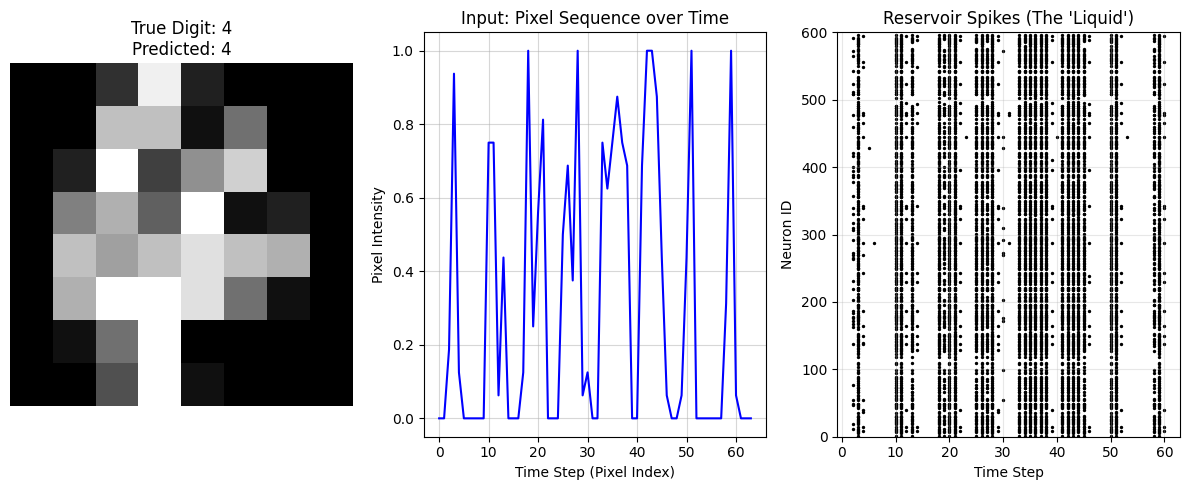

In [32]:
# ==========================================
# 3. Visualization for your Presentation
# ==========================================
# FIX: Strictly enforcing the index to grab exactly ONE sequence
samplex_idx = 99
sample_seq = X_test[samplex_idx]
sample_label = y_test[samplex_idx]
predicted_label = predictions[samplex_idx]

_, spike_history = lsm.get_liquid_state(sample_seq, return_spikes=True)

fig = plt.figure(figsize=(12, 5))

# Plot 1: The Original 8x8 Image
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(sample_seq.reshape(8, 8), cmap='gray')
ax1.set_title(f"True Digit: {sample_label}\nPredicted: {predicted_label}")
ax1.axis('off')

# Plot 2: The Sequential Pixel Input
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(sample_seq[:, 0], color='blue', linewidth=1.5)
ax2.set_title("Input: Pixel Sequence over Time")
ax2.set_xlabel("Time Step (Pixel Index)")
ax2.set_ylabel("Pixel Intensity")
ax2.grid(True, alpha=0.5)

# Plot 3: The Reservoir's Response (Raster Plot)
ax3 = fig.add_subplot(1, 3, 3)
spike_times, neuron_ids = np.where(spike_history == 1)
ax3.scatter(spike_times, neuron_ids, s=2, color='black')
ax3.set_title("Reservoir Spikes (The 'Liquid')")
ax3.set_xlabel("Time Step")
ax3.set_ylabel("Neuron ID")
ax3.set_ylim(0, RESERVOIR_SIZE)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()